### Testing space for uMux model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from uMux_modeling.include.model import *

In [2]:

loaded_data = np.loadtxt('NIST_full_s21.txt', dtype=complex)

freqs_loaded = np.real(loaded_data[:, 0])
s21_loaded = loaded_data[:, 1]
s21_db_loaded = np.abs(s21_loaded) 
s21_phase = np.angle(s21_loaded)
s21_logMag = 20*np.log10(s21_db_loaded)
s21_logMag = s21_logMag-np.max(s21_logMag)



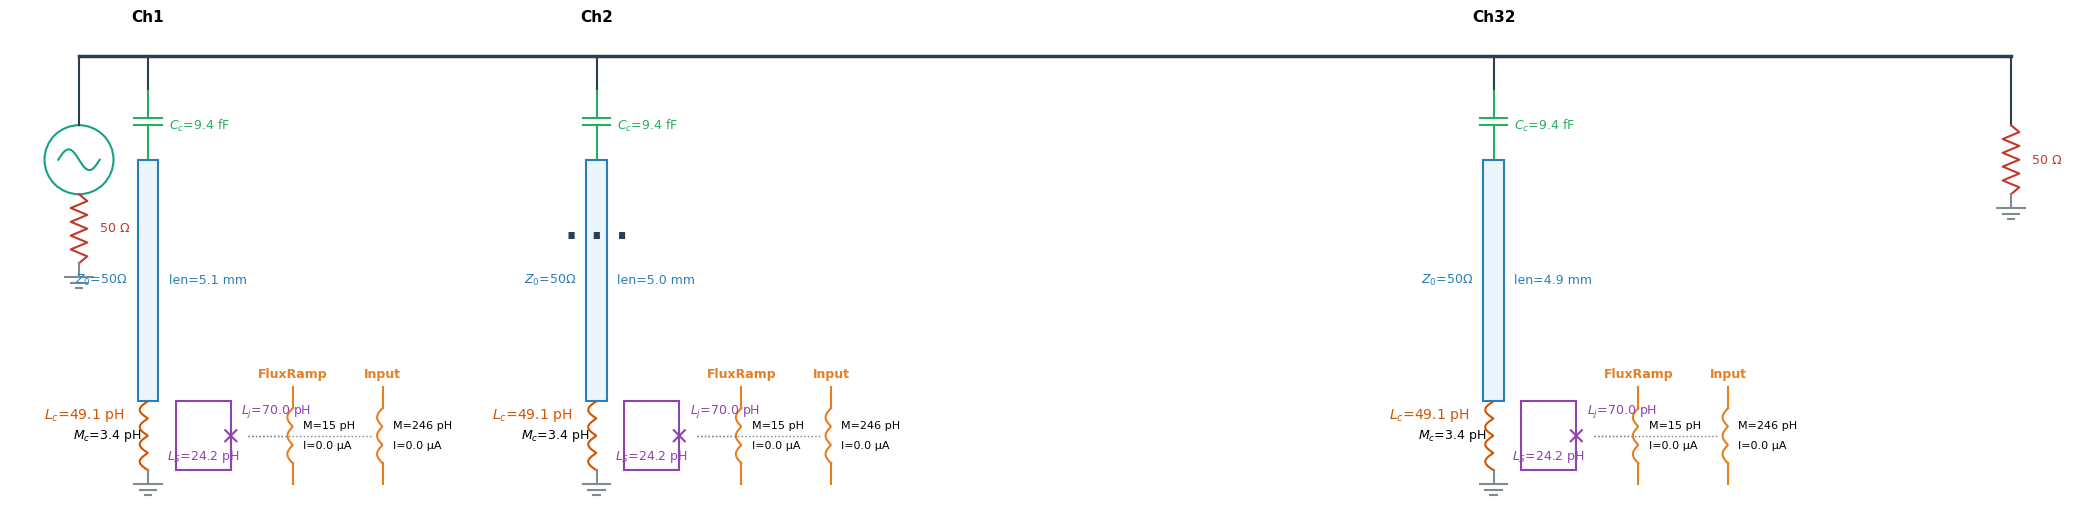

In [3]:
loaded_params = np.loadtxt('NIST_full_params.txt', dtype=float)

VNA = VNA_Simulator(z0=50)
Phi0 = 2.067e-15

squids = []

count = 1
for params in loaded_params:
    #if((params[2] > 5.6e9)&(params[2]<5.61e9)):
    squid_ch = SQUID(L_j=70e-12, L_s=24.2e-12, phi_ext=0)
    squid_ch.add_flux_line("FluxRamp", 15e-12)
    squid_ch.add_flux_line("Input", 246e-12)   
    ind_ch = Inductor(49.1e-12)
    tuned_L_ch = ScreenedInductor(primary_inductor=ind_ch, screening_device=squid_ch, M=3.4e-12)

    squids.append(squid_ch)

    length, Cc_val, Qi_val = extract_physical_params(params, tuned_L_ch, Cc_in=9.4e-15)

    cap_ch = Capacitor(C=Cc_val)
    phys_res = Resonator(length=length, load=tuned_L_ch, v_p=1.15e8, Qi=Qi_val)

    channel = Channel(name=f"Ch{count}")
    channel.add(cap_ch)
    channel.add(phys_res)
    VNA.add(channel, 'shunt')

    count += 1

VNA.draw_schematic(use_color=True, max_draw=1)

(25616, 2, 2)


/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


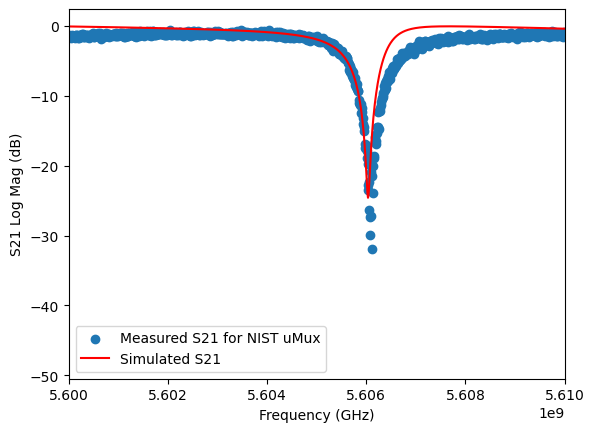

In [4]:
S = VNA.get_s_matrix(freqs_loaded)

plt.scatter(freqs_loaded, s21_logMag, label = "Measured S21 for NIST uMux")
plt.plot(freqs_loaded, 20*np.log10(S[1,0]), color = 'r', label = "Simulated S21")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Log Mag (dB)")
plt.legend()
plt.xlim([5.6e9,5.61e9])
plt.show()

In [5]:

    


I_array = np.linspace(0,300e-6,1000)
flux_array = []

for squid in squids:
    squid.flux_lines["FluxRamp"].I = I_array
    flux_array.append(I_array*squid.flux_lines["FluxRamp"].M)
    
S = VNA.get_s_matrix(freqs_loaded)

frs = []
for i in range(len(I_array)):
    fr_array = np.array([])
    peaks = find_all_peaks(freqs_loaded, S[i][1,0])
    freqs = freqs_loaded[peaks]
    frs.append(freqs)
    freqs = []
frs = np.transpose(frs)

print(np.shape(frs))

(25616, 1000, 2, 2)


/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/scipy/signal/_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


(32, 1000)


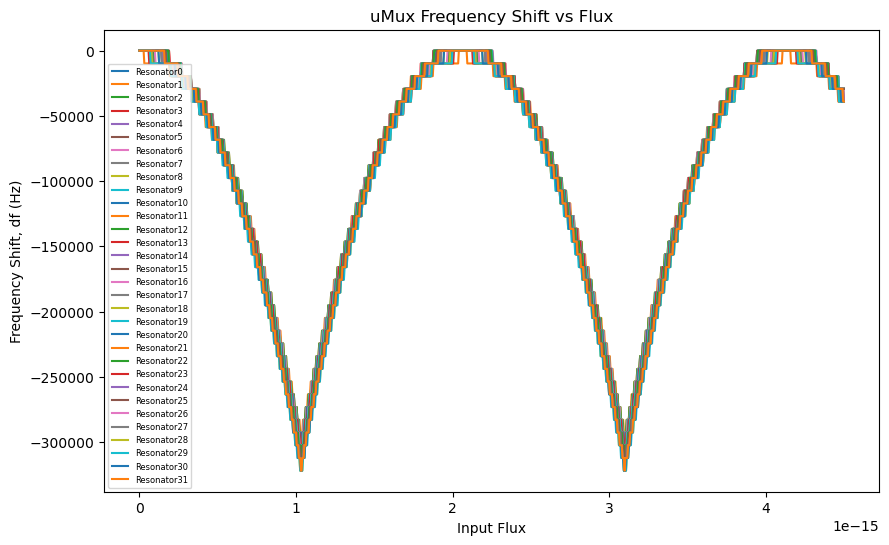

In [6]:

dfs = frs - frs[:, 0:1]

plt.figure(figsize=(10, 6))
for p in range(32):
    plt.plot(flux_array[0], dfs[p], label = "Resonator"+str(p))

plt.xlabel("Input Flux")
plt.ylabel("Frequency Shift, df (Hz)")
plt.title("uMux Frequency Shift vs Flux")
plt.legend(markerscale = 0.1, fontsize = 6)
plt.show()